In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [7]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['target_instances', 'd', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['target_instances', 'd'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['target_instances', 'd', 'method', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, topk_df




In [8]:
#Read data (remove v = 0.05 because we chose not to include it)
data_gaussian = pd.read_csv('results/gaussian.csv')
data_gaussian = data_gaussian[data_gaussian['v'] == 0.1]
data_slash = pd.read_csv('results/slash.csv')
data_slash = data_slash[data_slash['v'] == 0.1]
data_t= pd.read_csv('results/t.csv')
data_t = data_t[data_t['v'] == 0.1]

# Here we make final vizes!

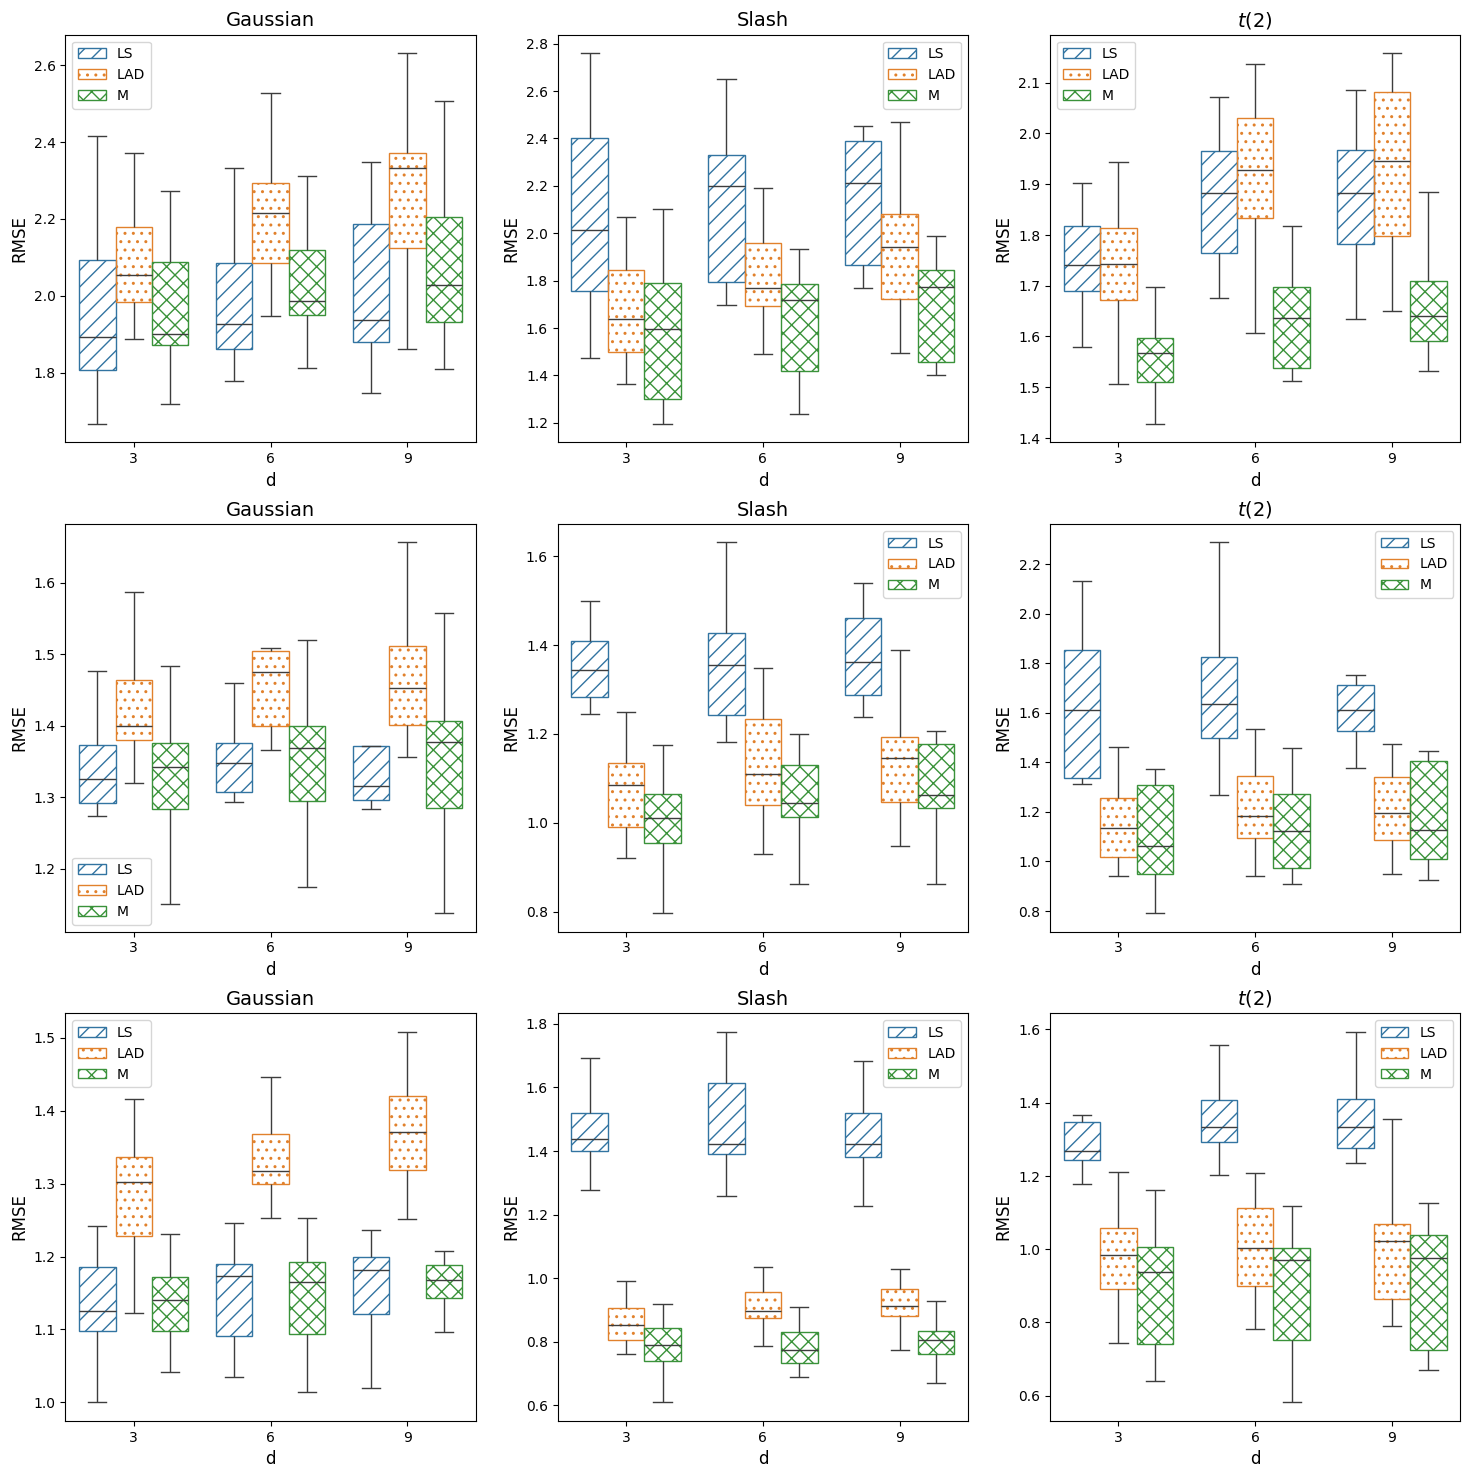

In [9]:

plt.figure(figsize = (18,18))
config_cols = ['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k']
import matplotlib as mpl
# Here we find the optimal settings (top5x5 = 25 total RMSEs)
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']
LS_data_gaussian['method'] = 'LS'
LAD_data_gaussian['method'] = 'LAD'
Huber_data_gaussian['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
    config_cols, k=25
)

i = 1

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('Gaussian', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3



i = 2

# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']
LS_data_slash['method'] = 'LS'
LAD_data_slash['method'] = 'LAD'
Huber_data_slash['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
    config_cols, k=25
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('Slash', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3


i = 3
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']
LS_data_t['method'] = 'LS'
LAD_data_t['method'] = 'LAD'
Huber_data_t['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
    config_cols, k=25
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('$t(2)$', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3

plt.subplots_adjust(hspace=0.2)  # increase horizontal spacing
plt.savefig('vizes/ls_lad_huber.png', bbox_inches = 'tight', pad_inches = 0.05, dpi = 300)


In [10]:
#Find default hyperparams here

target_instances_list = [100, 300, 500]
for target_instances in target_instances_list:
    cols = ['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k']
    params = Huber_data_gaussian.copy() #initialize params
    params = params[(params['seed'] == 86) & (params['d'] == 3) & (params['target_instances'] == 100)] #just to have same size as parameter space
    params = params[cols]
    params['total_rank'] = 0 #initialize total rank
    for dataset in [data_gaussian, data_t, data_slash]:
        Huber_data = dataset[dataset['method'] == 'MTransferTreeBoost'].copy()
        Huber_data = Huber_data[Huber_data['target_instances'] == target_instances]
        Huber_data['method'] = 'M'
        

        best_Huber, best_Huber_params = topk_per_d_per_method(Huber_data, config_cols, k=50) #top10 settings
        best_Huber_params = best_Huber_params.iloc[range(0, len(best_Huber_params), 5)] #every fifth cause of 5 seeds

        
        best_Huber_params = best_Huber_params[cols]
        # increment total_rank for matching parameter rows
        for _, row in best_Huber_params.iterrows():
            mask = (params[cols] == row[cols]).all(axis=1)
            params.loc[mask, 'total_rank'] += 1

    params = params.sort_values(by = 'total_rank', ascending = False)
    params.to_csv(f'optimal_params/optimal_params_Huber_{target_instances}.csv')

In [11]:
#Find default hyperparams here (LS)

target_instances_list = [100, 300, 500]
for target_instances in target_instances_list:
    cols = ['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k']
    params = LS_data_gaussian.copy() #initialize params
    params = params[(params['seed'] == 86) & (params['d'] == 3) & (params['target_instances'] == 100)] #just to have same size as parameter space
    params = params[cols]
    params['total_rank'] = 0 #initialize total rank
    for dataset in [data_gaussian, data_t, data_slash]:
        LS_data = dataset[dataset['method'] == 'MTransferTreeBoost'].copy()
        LS_data = LS_data[LS_data['target_instances'] == target_instances]
        LS_data['method'] = 'LS'
        

        best_LS, best_LS_params = topk_per_d_per_method(LS_data, config_cols, k=1000) #top5 settings
        best_LS_params = best_LS_params.iloc[range(0, len(best_LS_params), 5)] #every fifth cause of 5 seeds

        
        #best_LS_params = best_LS_params[cols]
        # increment total_rank for matching parameter rows
        for _, row in best_LS_params.iterrows():
            mask = (params[cols] == row[cols]).all(axis=1)
            params.loc[mask, 'total_rank'] += row['avg_rmse']

    params = params.sort_values(by = 'total_rank')
    params.to_csv(f'optimal_params/optimal_params_Huber_{target_instances}.csv')